# LEGO GINN Model: Mesh Extraction, Visualization, and Latent Space Analysis

This notebook demonstrates how to load a trained GINN model checkpoint for the LEGO 1xN dataset, extract and visualize shapes, analyze mesh connectivity, and perform latent space optimization.

**Outline:**
1. Import Required Libraries
2. Load Model Checkpoint and Configuration for LEGO Dataset
3. Sample Latent Vectors for LEGO Shapes
4. Extract and Visualize Meshes for LEGO Latents
5. Compare Mesh Connectivity and Statistics
6. Latent Space Grid Mapping for LEGO
7. Latent Space Optimization for LEGO (e.g., Target Volume)
8. Visualize Optimization Results for LEGO


In [20]:
# 1. Import Required Libraries
import sys
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
import k3d
from tqdm import tqdm
import trimesh
from util.checkpointing import load_yaml_and_drop_keys
from util.misc import get_model
from models.net_w_partials import NetWithPartials
from train.train_utils.latent_sampler import LatentSampler
from util.visualization.utils_mesh import get_watertight_mesh_for_latent


In [21]:
# Authoritative checkpoint loader - loads LEGO 1xN checkpoint and run config
import glob, os, torch
from pathlib import Path

# Prefer LEGO checkpoints under path/to/dir/cond_wire (where lego_1xN_wire.yml saves)
lego_ckpt_candidates = sorted(
    glob.glob('../path/to/dir/cond_wire/**/*-model.pt', recursive=True),
    key=os.path.getmtime
)
# Fallback: any cond_wire checkpoint whose run config has problem_str == 'lego_1xN'
other_ckpt_candidates = sorted(
    glob.glob('../checkpoints/cond_wire/**/*-model.pt', recursive=True),
    key=os.path.getmtime
)

ckpt_path = None
run_config_path = None
if len(lego_ckpt_candidates) > 0:
    ckpt_path = lego_ckpt_candidates[-1]
    run_config_path = Path(ckpt_path).parent / (Path(ckpt_path).parent.name + '-config.yml')
else:
    for cand in reversed(other_ckpt_candidates):
        run_dir = Path(cand).parent
        config_cand = run_dir / (run_dir.name + '-config.yml')
        if config_cand.exists():
            run_cfg_tmp = load_yaml_and_drop_keys(str(config_cand), keys_to_drop=[])
            pstr = (run_cfg_tmp.get('problem') or {}).get('problem_str') or run_cfg_tmp.get('problem_str')
            if pstr == 'lego_1xN':
                ckpt_path = cand
                run_config_path = config_cand
                break
    if ckpt_path is None and len(other_ckpt_candidates) > 0:
        ckpt_path = other_ckpt_candidates[-1]
        run_config_path = Path(ckpt_path).parent / (Path(ckpt_path).parent.name + '-config.yml')
        if not run_config_path.exists():
            run_config_path = None

if ckpt_path is None:
    print('No LEGO/cond_wire checkpoints found; will use YAML-only fallback for model_args.')
    ckpt = None
    model_args = None
else:
    print('Loading checkpoint:', ckpt_path)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    print('ckpt keys:', list(ckpt.keys()))
    # Prefer run config YAML next to checkpoint (authoritative for LEGO)
    if run_config_path is not None and Path(run_config_path).exists():
        run_cfg = load_yaml_and_drop_keys(str(run_config_path), keys_to_drop=[])
        config = run_cfg  # for bounds, mc_resolution, problem in later cells
        model_args = (run_cfg.get('model') or run_cfg.get('model_args') or {}).copy()
        # get_model expects hidden layers only and mutates the list; normalize full spec [nx+nz, 128, 128, 128, 1] -> [128, 128, 128]
        if model_args.get('layers'):
            L = model_args['layers']
            if len(L) >= 3 and L[0] in (5, 3+2) and L[-1] == 1:
                model_args['layers'] = L[1:-1]
        print('Loaded model_args from run config:', run_config_path)
    else:
        cfg = ckpt.get('config', None) or (ckpt.get('model', {}) or {}).get('config', None)
        if isinstance(cfg, dict):
            model_args = (cfg.get('model') or cfg.get('model_args') or {}).copy()
            if model_args.get('layers') and len(model_args['layers']) >= 3:
                L = model_args['layers']
                if L[0] in (5, 3+2) and L[-1] == 1:
                    model_args['layers'] = L[1:-1]
        else:
            model_args = None
    print('Extracted model_args keys:', list(model_args.keys()) if isinstance(model_args, dict) else model_args)

Loading checkpoint: ../path/to/dir/cond_wire\2026_01_30__17_41_03-08thq9yr\2026_01_30__17_41_03-08thq9yr-model.pt
ckpt keys: ['state_dict', 'init_params']
Loaded model_args from run config: ..\path\to\dir\cond_wire\2026_01_30__17_41_03-08thq9yr\2026_01_30__17_41_03-08thq9yr-config.yml
Extracted model_args keys: ['density_iso_level', 'group_size_fwd_no_grad', 'layers', 'model_str', 'nx', 'ny', 'nz', 'return_density', 'use_density', 'w0', 'w0_initial', 'wire_scale']


## Load Model Checkpoint and Configuration for LEGO Dataset

We load the latest LEGO 1xN wire model checkpoint and its configuration. This ensures the correct architecture and latent dimension are used.

In [22]:
# Use authoritative `model_args` from run config when available; otherwise fall back to LEGO YAML
if 'model_args' in globals() and model_args is not None:
    print('Using model_args from run config (LEGO checkpoint).')
else:
    try:
        cfg = load_yaml_and_drop_keys('../configs/GINN/lego_1xN_wire.yml', keys_to_drop=[])
        if isinstance(cfg, dict):
            if 'model' in cfg:
                model_args = cfg['model'].copy()
            elif 'model_args' in cfg:
                model_args = cfg['model_args'].copy()
            else:
                model_args = {k: v for k, v in cfg.items() if k in ['model_str','nx','nz','return_density','layers','use_legacy_gabor','w0_initial','w0','wire_scale'] }
        else:
            raise RuntimeError('Config not a dict')
        print('Loaded model_args from configs/GINN/lego_1xN_wire.yml (fallback)')
    except Exception as _e:
        print('YAML fallback failed; using minimal LEGO defaults', _e)
        model_args = {'model_str':'cond_wire', 'nx':3, 'nz':2, 'return_density':False, 'layers':[128, 128, 128], 'w0_initial':18, 'wire_scale':6}
print('Debug: model_args to be used for model construction:', model_args)
# get_model mutates layers; pass a copy and ensure hidden-only
model_kw = {k: v for k, v in model_args.items() if k != 'layers'}
model_kw['layers'] = list(model_args.get('layers', [128, 128, 128]))
try:
    model = get_model(**model_kw)
except Exception as e:
    print('Error creating model with model_args; printing model_args for inspection')
    print(model_args)
    raise

# If we loaded a checkpoint dict earlier, load its weights into the freshly constructed model
if 'ckpt' in globals() and ckpt is not None:
    try:
        state = ckpt.get('model', ckpt.get('state_dict', None))
        if state is None:
            raise KeyError("No 'model' or 'state_dict' key found in checkpoint")
        model.load_state_dict(state)
        model.eval()
        setattr(model, '_weights_loaded_from_checkpoint', True)
        print('Loaded model weights from checkpoint into `model`.')
    except Exception as e:
        print('Failed to load weights from checkpoint into model:', e)
        setattr(model, '_weights_loaded_from_checkpoint', False)
else:
    setattr(model, '_weights_loaded_from_checkpoint', False)


Using model_args from run config (LEGO checkpoint).
Debug: model_args to be used for model construction: {'density_iso_level': 0.05, 'group_size_fwd_no_grad': 2097152, 'layers': [128, 128, 128], 'model_str': 'cond_wire', 'nx': 3, 'ny': 1, 'nz': 2, 'return_density': False, 'use_density': False, 'w0': 1.0, 'w0_initial': 18, 'wire_scale': 6}
Loaded model weights from checkpoint into `model`.


In [23]:
# Diagnostic inspection of the constructed model and parameters
print("Diagnostic: model object:", type(model))
print(model)
print('\nDiagnostic: Iterating model.net modules:')
try:
    for i, mod in enumerate(model.net):
        print(f"Module {i}: {mod.__class__.__name__}")
        print(f"  omega_0: {getattr(mod, 'omega_0', None)}")
        print(f"  scale_0: {getattr(mod, 'scale_0', None)}")
        print(f"  has freqs: {hasattr(mod, 'freqs')}")
        print(f"  has scale: {hasattr(mod, 'scale')}")
except Exception as e:
    print('Error iterating model.net:', e)

print('\nDiagnostic: model.named_parameters() sample:')
try:
    names = [n for n, p in model.named_parameters()]
    print('\n'.join(names[:50]))
except Exception as e:
    print('Error listing named_parameters:', e)

print('\nDiagnostic: Check for netp in globals')
if 'netp' in globals():
    try:
        print('netp exists: NetWithPartials instance? ->', type(netp))
        print('Sample param keys from netp.params:')
        print('\n'.join(list(netp.params.keys())[:200]))
    except Exception as e:
        print('Error inspecting netp:', e)
else:
    print('netp not defined in this notebook namespace')

Diagnostic: model object: <class 'models.wire.ConditionalWIRE'>
ConditionalWIRE(
  (net): Sequential(
    (0): RealGaborLayer(
      (freq_scale): Linear(in_features=5, out_features=256, bias=True)
    )
    (1): RealGaborLayer(
      (freq_scale): Linear(in_features=128, out_features=256, bias=True)
    )
    (2): RealGaborLayer(
      (freq_scale): Linear(in_features=128, out_features=256, bias=True)
    )
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Diagnostic: Iterating model.net modules:
Module 0: RealGaborLayer
  omega_0: 18
  scale_0: 6
  has freqs: False
  has scale: False
Module 1: RealGaborLayer
  omega_0: 1.0
  scale_0: 6
  has freqs: False
  has scale: False
Module 2: RealGaborLayer
  omega_0: 1.0
  scale_0: 6
  has freqs: False
  has scale: False
Module 3: Linear
  omega_0: None
  scale_0: None
  has freqs: False
  has scale: False

Diagnostic: model.named_parameters() sample:
net.0.freq_scale.weight
net.0.freq_scale.bias
net.1.freq_scale.weight
net.1

In [24]:
# Debugging RealGaborLayerLegacy initialization
from models.wire import RealGaborLayerLegacy
print("Debug: Inspecting RealGaborLayerLegacy initialization")
print(f"Debug: model_args = {model_args}")
try:
    # Filter model_args to include only valid arguments for RealGaborLayerLegacy
    valid_keys = ['return_density', 'layers', 'use_legacy_gabor']  # Updated valid keys
    filtered_args = {key: model_args[key] for key in valid_keys if key in model_args}
    print(f"Debug: filtered_args = {filtered_args}")
    gabor_layer = RealGaborLayerLegacy(**filtered_args)  # Replace with actual initialization
    print("Debug: RealGaborLayerLegacy initialized successfully")
    print(f"Debug: gabor_layer.freqs = {gabor_layer.freqs}")
    print(f"Debug: gabor_layer.scale = {gabor_layer.scale}")
except Exception as e:
    print("Error during RealGaborLayerLegacy initialization:", e)

Debug: Inspecting RealGaborLayerLegacy initialization
Debug: model_args = {'density_iso_level': 0.05, 'group_size_fwd_no_grad': 2097152, 'layers': [128, 128, 128], 'model_str': 'cond_wire', 'nx': 3, 'ny': 1, 'nz': 2, 'return_density': False, 'use_density': False, 'w0': 1.0, 'w0_initial': 18, 'wire_scale': 6}
Debug: filtered_args = {'return_density': False, 'layers': [128, 128, 128]}
Error during RealGaborLayerLegacy initialization: RealGaborLayerLegacy.__init__() got an unexpected keyword argument 'return_density'


## Sample Latent Vectors for LEGO Shapes

We generate or load latent vectors suitable for the LEGO model. These will be used to generate and analyze shapes.

In [25]:
# 3. Sample Latent Vectors for LEGO Shapes
# Ensure `config` is available (try loading from checkpoint), otherwise use sensible defaults
if 'config' not in globals():
    try:
        config = load_yaml_and_drop_keys('../checkpoints/GINN-config.yml', keys_to_drop=[])
        print("Loaded config from ../checkpoints/GINN-config.yml")
    except Exception as e:
        print("config not found, using fallback minimal config:", e)
        config = {'model': {'nz': model_args.get('nz', 2)}, 'latent_sampling': {}}
# Use LatentSampler if available, else random sampling
try:
    lat_sampler = LatentSampler(**config.get('latent_sampling', {}))
    z_latents = lat_sampler.val_z()
    print(f"Loaded {len(z_latents)} latent vectors from LatentSampler.")
except Exception as e:
    print("LatentSampler not available or failed, using random z. Error:", e)
    nz = config['model'].get('nz', model_args.get('nz', 2))
    n_shapes = 12
    z_min, z_max = 0.0, 0.1
    z_latents = torch.rand(n_shapes, nz, device=device) * (z_max - z_min) + z_min
    print(f"Generated {n_shapes} random latent vectors (nz={nz}).")
print(f"Sample z: {z_latents[:2]}")

Loaded 9 latent vectors from LatentSampler.
Sample z: tensor([[0.0000, 0.0000],
        [0.0000, 0.0500]])


## Extract and Visualize Meshes for LEGO Latents

For each sampled latent vector, extract the corresponding mesh using marching cubes and visualize the shapes using k3d.

In [26]:
# Debugging model_args before mesh extraction
# Ensure device is set
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print("Debug: device:", device)
# Ensure `netp` exists and params are on device
# Recreate `netp` from `model` if weights were just loaded from checkpoint or netp doesn't exist
need_recreate = ('netp' not in globals()) or (not getattr(model, '_weights_loaded_from_checkpoint', False))
if need_recreate:
    print('Creating NetWithPartials from model (ensuring checkpoint weights are used).')
    netp = NetWithPartials.create_from_model(model, nz=model_args.get('nz', 2), nx=model_args.get('nx', 3))
    netp.params = {k: v.to(device) for k, v in netp.params.items()}
else:
    # move params to device if necessary
    netp.params = {k: v.to(device) for k, v in netp.params.items()}

# Use run_cfg as config for bounds/meshing if config not set
if 'config' not in globals() or config is None:
    config = globals().get('run_cfg', {})
mc_resolution = 128
if isinstance(config, dict) and config:
    mc_resolution = config.get('meshing', {}).get('mc_resolution', 128) or mc_resolution
# Override with current LEGO config meshing when testing latest checkpoint (256, no reduction)
try:
    current_cfg = load_yaml_and_drop_keys('../configs/GINN/lego_1xN_wire.yml', keys_to_drop=[])
    mc_resolution = current_cfg.get('meshing', {}).get('mc_resolution', mc_resolution) or mc_resolution
except Exception:
    pass

# Determine bounds from authoritative problem if possible
from util.misc import get_problem
bounds = None
if 'cfg' in globals() and isinstance(cfg, dict) and 'problem' in cfg:
    try:
        problem = get_problem(problem_config=cfg['problem'], **cfg.get('problem_sampling', {}))
        bounds = problem.bounds.to(device)
        print('Using bounds from checkpoint problem:', bounds)
    except Exception as e:
        print('Failed to construct problem from cfg:', e)
        bounds = None

if bounds is None and 'config' in globals() and isinstance(config, dict) and 'problem' in config:
    try:
        problem = get_problem(problem_config=config['problem'], **config.get('problem_sampling', {}))
        bounds = problem.bounds.to(device)
        print('Using bounds from YAML config/problem:', bounds)
    except Exception as e:
        print('Failed to construct problem from config:', e)
        bounds = None

# Fallback to default if none found
if bounds is None:
    bounds = globals().get('bounds', torch.tensor([[-1., 1.], [-1., 1.], [-1., 1.]], device=device))

meshes = globals().get('meshes', [])
print("Debug: model_args:", model_args)
print("Debug: mc_resolution:", mc_resolution)
print("Debug: bounds:", bounds)
for z in tqdm(z_latents, desc="Extracting meshes"):
    z = z.to(device)
    mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
    meshes.append(mesh)


Debug: device: cuda:0
Created LEGO 1x4 problem:
  Bounds: [[-1.9874999523162842, 1.9874999523162842], [-0.48750001192092896, 0.48750001192092896], [-0.7124999761581421, 0.7124999761581421]]
  Stud centers (x): [-1.4875, -0.48750000000000004, 0.5125, 1.5125]
  Points: 16384 far_outside, 32768 outside, 16384 around_if, 4096 inside, 4092 interface
Using bounds from YAML config/problem: tensor([[-1.9875,  1.9875],
        [-0.4875,  0.4875],
        [-0.7125,  0.7125]], device='cuda:0')
Debug: model_args: {'density_iso_level': 0.05, 'group_size_fwd_no_grad': 2097152, 'layers': [128, 128, 128], 'model_str': 'cond_wire', 'nx': 3, 'ny': 1, 'nz': 2, 'return_density': False, 'use_density': False, 'w0': 1.0, 'w0_initial': 18, 'wire_scale': 6}
Debug: mc_resolution: 128
Debug: bounds: tensor([[-1.9875,  1.9875],
        [-0.4875,  0.4875],
        [-0.7125,  0.7125]], device='cuda:0')


Extracting meshes: 100%|██████████| 9/9 [00:00<00:00, 12.98it/s]


## Compare Mesh Connectivity and Statistics

Count connected components and vertices for each mesh. Print summary statistics (number of connected shapes, average components, average vertices).

In [27]:
# 5. Compare Mesh Connectivity and Statistics
results = []
for i, mesh in enumerate(meshes):
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    results.append({'n_components': n_components, 'n_vertices': len(verts)})

n_connected = sum(1 for r in results if r['n_components'] == 1)
avg_components = np.mean([r['n_components'] for r in results])
avg_vertices = np.mean([r['n_vertices'] for r in results])
print(f"Connected (1 comp): {n_connected}/{len(results)}")
print(f"Avg components: {avg_components:.2f}")
print(f"Avg vertices: {avg_vertices:.0f}")
for i, r in enumerate(results):
    print(f"Shape {i+1}: {r['n_components']} components, {r['n_vertices']} vertices")

Connected (1 comp): 0/18
Avg components: 3.78
Avg vertices: 23951
Shape 1: 6 components, 24178 vertices
Shape 2: 2 components, 23874 vertices
Shape 3: 3 components, 24152 vertices
Shape 4: 4 components, 23882 vertices
Shape 5: 3 components, 23610 vertices
Shape 6: 3 components, 23880 vertices
Shape 7: 5 components, 24138 vertices
Shape 8: 4 components, 23792 vertices
Shape 9: 4 components, 24056 vertices
Shape 10: 6 components, 24178 vertices
Shape 11: 2 components, 23874 vertices
Shape 12: 3 components, 24152 vertices
Shape 13: 4 components, 23882 vertices
Shape 14: 3 components, 23610 vertices
Shape 15: 3 components, 23880 vertices
Shape 16: 5 components, 24138 vertices
Shape 17: 4 components, 23792 vertices
Shape 18: 4 components, 24056 vertices


## Latent Space Grid Mapping for LEGO

Create a grid of latent vectors across the LEGO latent space, extract meshes, and visualize the grid to show how shape connectivity varies.

In [28]:
# 6. Latent Space Grid Mapping for LEGO
nz = config['model']['nz']
grid_size = 5
z_min, z_max = 0.0, 0.1
z1_vals = torch.linspace(z_min, z_max, grid_size)
z2_vals = torch.linspace(z_min, z_max, grid_size)
z_grid = []
for z1 in z1_vals:
    for z2 in z2_vals:
        z_grid.append(torch.tensor([z1.item(), z2.item()][:nz], device=device))

meshes_grid = []
connectivity_grid = []
for z in tqdm(z_grid, desc="Grid meshes"):
    mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
    meshes_grid.append(mesh)
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    connectivity_grid.append(n_components)

# Visualize grid
spacing = 1.8 * (bounds[:, 1] - bounds[:, 0]).cpu().numpy()
fig = k3d.plot(height=900)
for idx, (mesh, n_comp, z) in enumerate(zip(meshes_grid, connectivity_grid, z_grid)):
    row = idx // grid_size
    col = idx % grid_size
    verts, faces = mesh
    if len(verts) > 0:
        color = 0x3498db if n_comp == 1 else 0xe74c3c
        fig += k3d.mesh(verts, faces, color=color, side='double', translation=[col*spacing[0], row*spacing[1], 0], name=f"z=[{z[0]:.2f},{z[1]:.2f}] ({n_comp} comp)")
fig.display()
print(f"Connected (1 comp): {sum(1 for c in connectivity_grid if c == 1)}/{len(connectivity_grid)}")

Grid meshes:   0%|          | 0/25 [00:00<?, ?it/s]

Grid meshes: 100%|██████████| 25/25 [00:02<00:00,  9.66it/s]


Output()

Connected (1 comp): 0/25


## Latent Space Optimization

Optimize a latent vector to maximize mesh connectivity or match a target property. This section demonstrates gradient-based optimization in the latent space for the LEGO GINN model.

In [29]:
# 7. Latent Space Optimization Example
# Connectivity (n_components) is not differentiable; use gradient-free search.

# Start from a random latent (gradient-free: connectivity is not differentiable)
z_opt = torch.randn(nz, device=device)
perturb_scale = 0.1  # step size for random perturbations

# Target: maximize number of mesh components == 1 (i.e., connected mesh)
num_steps = 30
best_z = z_opt.detach().clone()
best_score = -float('inf')

def score_latent(z):
    mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
    verts, faces = mesh
    if len(verts) > 0 and len(faces) > 0:
        try:
            tm = trimesh.Trimesh(vertices=verts, faces=faces)
            n_components = len(tm.split(only_watertight=False))
        except Exception:
            n_components = -1
    else:
        n_components = 0
    return (1.0 if n_components == 1 else -n_components), n_components

for step in range(num_steps):
    score, n_components = score_latent(z_opt)
    if score > best_score:
        best_score = score
        best_z = z_opt.detach().clone()
    # Perturb z (gradient-free hill climbing)
    z_opt = z_opt + perturb_scale * torch.randn(nz, device=device)
    print(f"Step {step+1}: n_components={n_components}, score={score}")

# Visualize optimized mesh
mesh = get_watertight_mesh_for_latent(netp.f_, netp.params, best_z, bounds, mc_resolution, device, chunks=1, level=0, surpress_watertight=True)
verts, faces = mesh
if len(verts) > 0:
    fig = k3d.plot(height=600)
    fig += k3d.mesh(verts, faces, color=0x2ecc71, side='double', name='Optimized')
    fig.display()
else:
    print("No mesh generated from optimized latent.")

Step 1: n_components=33, score=-33
Step 2: n_components=32, score=-32
Step 3: n_components=25, score=-25
Step 4: n_components=29, score=-29
Step 5: n_components=25, score=-25
Step 6: n_components=21, score=-21
Step 7: n_components=16, score=-16
Step 8: n_components=14, score=-14
Step 9: n_components=16, score=-16
Step 10: n_components=15, score=-15
Step 11: n_components=16, score=-16
Step 12: n_components=18, score=-18
Step 13: n_components=14, score=-14
Step 14: n_components=16, score=-16
Step 15: n_components=15, score=-15
Step 16: n_components=14, score=-14
Step 17: n_components=18, score=-18
Step 18: n_components=17, score=-17
Step 19: n_components=15, score=-15
Step 20: n_components=19, score=-19
Step 21: n_components=16, score=-16
Step 22: n_components=24, score=-24
Step 23: n_components=19, score=-19
Step 24: n_components=23, score=-23
Step 25: n_components=23, score=-23
Step 26: n_components=15, score=-15
Step 27: n_components=15, score=-15
Step 28: n_components=8, score=-8
Ste

Output()

## Visualization and Summary

Summarize findings, visualize key results, and discuss the implications of latent space structure and mesh connectivity for the LEGO GINN model.

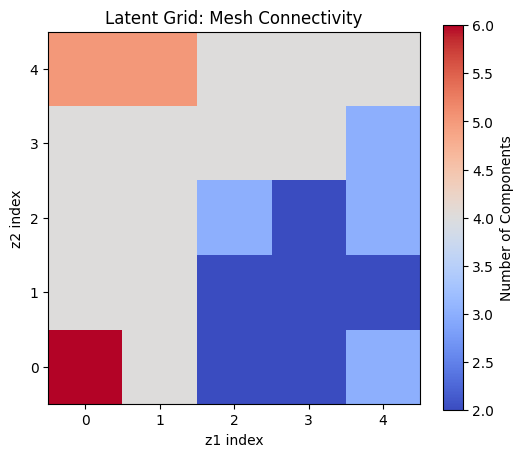

Connected meshes in grid: 0/25
Best optimized latent produced a disconnected mesh.


In [30]:
# 8. Visualization and Summary
# Show a summary plot of grid connectivity and optimized mesh
import matplotlib.pyplot as plt

# Grid connectivity heatmap
conn_arr = np.array(connectivity_grid).reshape((grid_size, grid_size))
plt.figure(figsize=(6,5))
plt.imshow(conn_arr, cmap='coolwarm', origin='lower')
plt.colorbar(label='Number of Components')
plt.title('Latent Grid: Mesh Connectivity')
plt.xlabel('z1 index')
plt.ylabel('z2 index')
plt.show()

# Print summary
n_connected = sum(1 for c in connectivity_grid if c == 1)
print(f"Connected meshes in grid: {n_connected}/{len(connectivity_grid)}")
print(f"Best optimized latent produced {'a connected mesh' if best_score == 1.0 else 'a disconnected mesh'}.")